# **Complete CNN anemia eye model**

In [2]:
!pip install torch torchvision matplotlib seaborn scikit-learn pandas pillow -q

In [3]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Mount Google Drive
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Imports
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
import os, random, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from PIL import Image
from collections import Counter

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, f1_score
)

warnings.filterwarnings("ignore")
torch.manual_seed(42)
np.random.seed(42)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device : {DEVICE}")
print(f"PyTorch: {torch.__version__}")


Device : cuda
PyTorch: 2.11.0+cu128


In [5]:

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# ⚙️  CONFIG  (only edit this cell)
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# ┌─────────────────────────────────────────────────────────────┐
# │  FOLDER STRUCTURE EXPECTED:                                 │
# │                                                             │
# │  /content/drive/MyDrive/anemia_dataset/                     │
# │      Patient_001/                                           │
# │          eye1.jpg                                           │
# │          eye1_palpebral.png                                 │
# │          eye1_forniceal.png                                 │
# │      Patient_002/                                           │
# │          eye2.jpg   ...                                     │
# │      labels.csv  ← Number | Hgb | Gender | Age             │
# └─────────────────────────────────────────────────────────────┘

DATASET_DIR  = "/content/drive/MyDrive/dataset anemia/India"   # ← CHANGE THIS
LABELS_CSV   = "/content/drive/MyDrive/dataset anemia/India/India.xlsx"  # ← CHANGE THIS

# Anemia threshold (WHO standard)
ANEMIA_THRESHOLD = 12.0   # Hgb < 12 → Anemic

# Image settings
IMG_SIZE     = 224
BATCH_SIZE   = 8           # small batch because dataset is small (3-5 imgs/patient)
EPOCHS       = 100
LR           = 1e-4
WEIGHT_DECAY = 1e-4

# Output folder (saves model + plots)
OUTPUT_DIR   = "/content/outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("Config loaded ✓")
print(f"Dataset : {DATASET_DIR}")
print(f"Labels  : {LABELS_CSV}")


Config loaded ✓
Dataset : /content/drive/MyDrive/dataset anemia/India
Labels  : /content/drive/MyDrive/dataset anemia/India/India.xlsx


In [6]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# 🔍 SCAN DATASET  (see what you have)
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
def scan_dataset(dataset_dir):
    """
    Scans your folder and shows exactly what images are found.
    Run this first to verify your folder structure is correct.
    """
    root = Path(dataset_dir)
    IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".tiff"}

    total_patients = 0
    total_images   = 0
    imgs_per_patient = []

    print(f"\n{'='*55}")
    print(f"  Scanning: {dataset_dir}")
    print(f"{'='*55}")

    for folder in sorted(root.iterdir()):
        if not folder.is_dir():
            continue
        imgs = [f for f in folder.iterdir() if f.suffix.lower() in IMAGE_EXTS]
        if len(imgs) == 0:
            continue
        total_patients += 1
        total_images   += len(imgs)
        imgs_per_patient.append(len(imgs))
        print(f"  {folder.name:20s} → {len(imgs)} images")
        for img in imgs:
            print(f"      {img.name}")

    print(f"\n  Total patients  : {total_patients}")
    print(f"  Total images    : {total_images}")
    print(f"  Avg imgs/patient: {np.mean(imgs_per_patient):.1f}")
    print(f"  Min / Max       : {min(imgs_per_patient)} / {max(imgs_per_patient)}")
    return total_patients, total_images

scan_dataset(DATASET_DIR)



  Scanning: /content/drive/MyDrive/dataset anemia/India
  1                    → 4 images
      20200118_164733_forniceal.png
      20200118_164733_palpebral.png
      20200118_164733_forniceal_palpebral.png
      20200118_164733.jpg
  10                   → 4 images
      20200203_091841_forniceal.png
      20200203_091841_forniceal_palpebral.png
      20200203_091841.jpg
      20200203_091841_palpebral.png
  11                   → 4 images
      20200203_094523_forniceal.png
      20200203_094523_palpebral.png
      20200203_094523.jpg
      20200203_094523_forniceal_palpebral.png
  12                   → 4 images
      20200203_103722.jpg
      20200203_103722_forniceal_palpebral.png
      20200203_103722_forniceal.png
      20200203_103722_palpebral.png
  13                   → 4 images
      20200203_190841.jpg
      20200203_190841_palpebral.png
      20200203_190841_forniceal.png
      20200203_190841_forniceal_palpebral.png
  14                   → 4 images
      20200204_1542

(95, 382)

In [7]:
import pandas as pd

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# 📋 LOAD LABELS
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
def load_labels(csv_path, threshold):
    df = pd.read_excel(csv_path)  # Changed to pd.read_excel
    df.columns = df.columns.str.strip().str.lower()

    # Rename 'number' to 'patient_id' for clarity
    if "number" in df.columns:
        df = df.rename(columns={"number": "patient_id"})

    # Binary label: 1 = Anemic, 0 = Non-Anemic
    df["label"] = (df["hgb"] < threshold).astype(int)

    print(f"\nLabels loaded: {len(df)} patients")
    print(df[["patient_id", "hgb", "label"]].head(10).to_string(index=False))
    print(f"\nAnemic    : {df['label'].sum()}")
    print(f"Non-Anemic: {(df['label']==0).sum()}")

    return df

label_df = load_labels(LABELS_CSV, ANEMIA_THRESHOLD)



Labels loaded: 95 patients
 patient_id  hgb  label
          1 12.2      0
          2  8.0      1
          3 10.7      1
          4  8.3      1
          5  7.8      1
          6 11.8      1
          7  9.2      1
          8 13.0      0
          9 11.5      1
         10 11.3      1

Anemic    : 56
Non-Anemic: 39


In [8]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# 🗂️  BUILD RECORDS  (image path + label per image)
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
def build_records(dataset_dir, label_df):
    """
    Each patient has 3-5 images.
    All images of a patient get the SAME label (patient-level label).
    This increases the dataset size naturally.
    """
    root = Path(dataset_dir)
    IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp"}
    records = []
    missing = []

    for _, row in label_df.iterrows():
        pid   = int(row["patient_id"])
        label = int(row["label"])
        hgb   = float(row["hgb"])

        # Try common folder naming patterns
        folder_names = [
            f"Patient_{pid:03d}",
            f"Patient_{pid}",
            f"patient_{pid:03d}",
            f"{pid:03d}",
            f"{pid}",
        ]

        folder = None
        for name in folder_names:
            candidate = root / name
            if candidate.exists():
                folder = candidate
                break

        if folder is None:
            missing.append(pid)
            continue

        # Get all images in this patient's folder
        imgs = [f for f in sorted(folder.iterdir())
                if f.suffix.lower() in IMAGE_EXTS]

        for img_path in imgs:
            records.append({
                "image_path": str(img_path),
                "label":      label,
                "hgb":        hgb,
                "patient_id": pid,
                "img_name":   img_path.name,
            })

    print(f"\nRecords built:")
    print(f"  Total images found : {len(records)}")
    print(f"  Patients missing   : {len(missing)} {missing[:5] if missing else ''}")
    print(f"  Anemic images      : {sum(1 for r in records if r['label']==1)}")
    print(f"  Non-Anemic images  : {sum(1 for r in records if r['label']==0)}")

    return records

records = build_records(DATASET_DIR, label_df)



Records built:
  Total images found : 382
  Patients missing   : 0 
  Anemic images      : 224
  Non-Anemic images  : 158


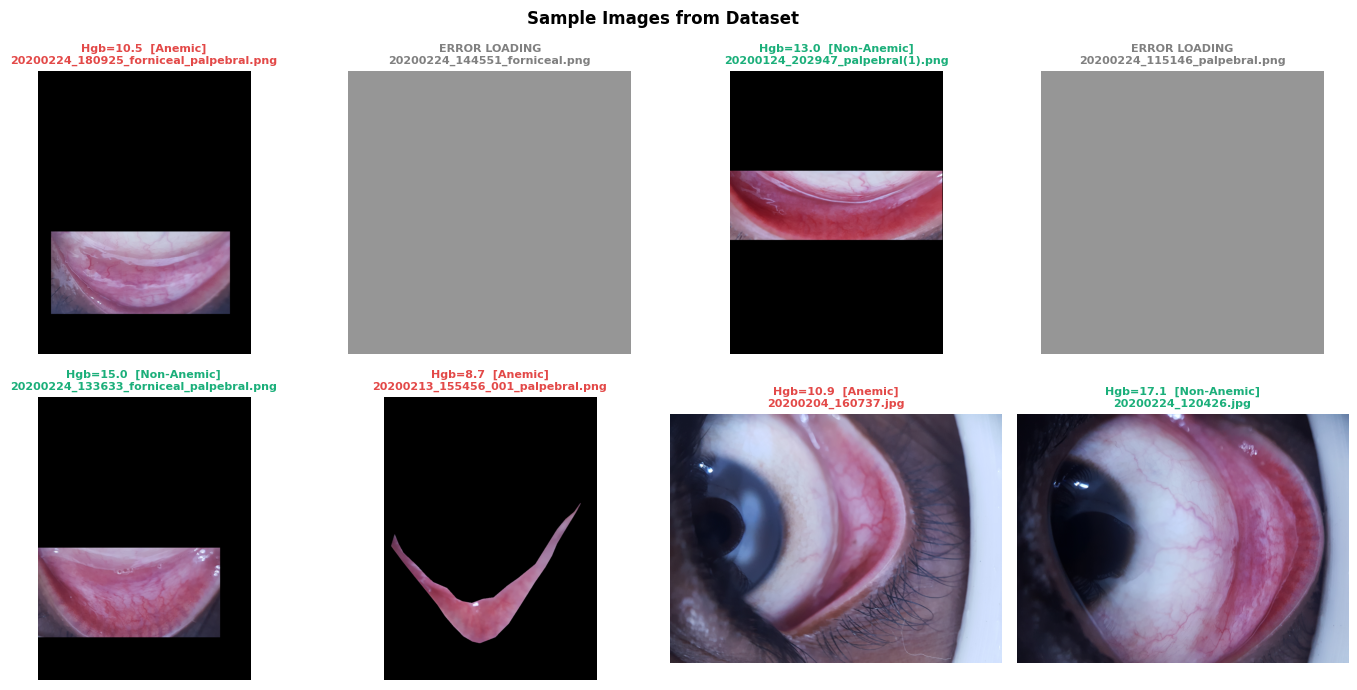

Sample grid saved ✓


In [9]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# 👁️  SHOW SAMPLE IMAGES
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
def show_samples(records, n=8):
    sample = random.sample(records, min(n, len(records)))
    cols = 4
    rows = (len(sample) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(14, rows * 3.5))
    axes = axes.flatten() if rows > 1 else [axes] if cols == 1 else axes.flatten()

    for i, rec in enumerate(sample):
        try:
            img = Image.open(rec["image_path"]).convert("RGB")
            label_str = "Anemic" if rec["label"] == 1 else "Non-Anemic"
            color = "#e34948" if rec["label"] == 1 else "#1baf7a"
            title_text = f"Hgb={rec['hgb']}  [{label_str}]\n{rec['img_name']}"
        except Exception as e:
            print(f"Warning: Could not open image {rec['image_path']}. Error: {e}")
            img = Image.new("RGB", (IMG_SIZE, IMG_SIZE), (150, 150, 150)) # Placeholder image
            title_text = f"ERROR LOADING\n{rec['img_name']}"
            color = "#808080"

        axes[i].imshow(img)
        axes[i].set_title(
            title_text,
            fontsize=8, color=color, fontweight="bold"
        )
        axes[i].axis("off")

    for j in range(i+1, len(axes)):
        axes[j].axis("off")

    plt.suptitle("Sample Images from Dataset", fontsize=12, fontweight="bold")
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/sample_images.png", dpi=120, bbox_inches="tight")
    plt.show()
    print("Sample grid saved ✓")

show_samples(records)


In [10]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# ✂️  PATIENT-LEVEL SPLIT
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# IMPORTANT: Split by PATIENT not by IMAGE.
# If same patient's images appear in train and test,
# the model "memorises" that patient → fake high accuracy.

def patient_level_split(records, label_df, test_size=0.2, val_size=0.1, seed=42):
    # Get unique patients with their labels
    patient_labels = label_df.set_index("patient_id")["label"].to_dict()
    pids    = list(patient_labels.keys())
    plabels = [patient_labels[p] for p in pids]

    # Split patients (not images)
    train_pids, test_pids = train_test_split(
        pids, test_size=test_size,
        stratify=plabels, random_state=seed
    )
    train_labels = [patient_labels[p] for p in train_pids]
    train_pids, val_pids = train_test_split(
        train_pids, test_size=val_size / (1 - test_size),
        stratify=train_labels, random_state=seed
    )

    train_pids = set(train_pids)
    val_pids   = set(val_pids)
    test_pids  = set(test_pids)

    train_recs = [r for r in records if r["patient_id"] in train_pids]
    val_recs   = [r for r in records if r["patient_id"] in val_pids]
    test_recs  = [r for r in records if r["patient_id"] in test_pids]

    print(f"\nPatient-level split:")
    print(f"  Train: {len(train_pids)} patients → {len(train_recs)} images")
    print(f"  Val  : {len(val_pids)} patients → {len(val_recs)} images")
    print(f"  Test : {len(test_pids)} patients → {len(test_recs)} images")

    return train_recs, val_recs, test_recs

train_recs, val_recs, test_recs = patient_level_split(records, label_df)



Patient-level split:
  Train: 66 patients → 266 images
  Val  : 10 patients → 40 images
  Test : 19 patients → 76 images


In [11]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# 🔄 TRANSFORMS  (augmentation)
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# For small datasets, heavy augmentation is very important.
# It artificially creates more training examples.

MEAN = [0.485, 0.456, 0.406]   # ImageNet mean (works for medical images too)
STD  = [0.229, 0.224, 0.225]   # ImageNet std

train_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE + 32, IMG_SIZE + 32)),
    transforms.RandomCrop(IMG_SIZE),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.3),
    transforms.RandomRotation(degrees=20),
    transforms.ColorJitter(
        brightness=0.4,   # lighting variation
        contrast=0.4,
        saturation=0.4,   # key: pallor detection needs saturation sensitivity
        hue=0.05
    ),
    transforms.RandomGrayscale(p=0.05),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

val_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

print("Transforms ready ✓")


Transforms ready ✓


In [12]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# 📦 DATASET CLASS
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
class EyeDataset(Dataset):
    def __init__(self, records, transform=None):
        self.records   = records
        self.transform = transform

    def __len__(self):
        return len(self.records)

    def __getitem__(self, idx):
        rec = self.records[idx]
        try:
            img = Image.open(rec["image_path"]).convert("RGB")
        except Exception:
            img = Image.new("RGB", (IMG_SIZE, IMG_SIZE), (200, 150, 150))

        if self.transform:
            img = self.transform(img)

        return (
            img,
            torch.tensor(rec["label"], dtype=torch.long),
            torch.tensor(rec["hgb"],   dtype=torch.float32)
        )


In [13]:

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# WEIGHTED SAMPLER (handle imbalance)
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
def make_weighted_sampler(records):
    """
    If you have more non-anemic than anemic patients,
    this sampler makes the model see them equally often.
    """
    labels = [r["label"] for r in records]
    counts = Counter(labels)
    weights = [1.0 / counts[l] for l in labels]
    sampler = WeightedRandomSampler(
        weights=weights,
        num_samples=len(weights),
        replacement=True
    )
    return sampler

# Datasets
train_ds = EyeDataset(train_recs, transform=train_tf)
val_ds   = EyeDataset(val_recs,   transform=val_tf)
test_ds  = EyeDataset(test_recs,  transform=val_tf)

# Weighted sampler for training only
sampler = make_weighted_sampler(train_recs)

# DataLoaders
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,    num_workers=2)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,    num_workers=2)

print(f"Train batches: {len(train_loader)}")
print(f"Val   batches: {len(val_loader)}")
print(f"Test  batches: {len(test_loader)}")


Train batches: 34
Val   batches: 5
Test  batches: 10


In [14]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# 🧠 CNN MODEL ARCHITECTURE
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
#
#  INPUT IMAGE (224×224×3)
#       │
#  ┌────▼──────────────────────────────────┐
#  │ BLOCK 1: Conv→BN→ReLU→Conv→BN→ReLU  │  32 filters, 3×3
#  │          MaxPool 2×2 → Dropout(0.25) │  → 112×112
#  ├───────────────────────────────────────┤
#  │ BLOCK 2: Conv→BN→ReLU→Conv→BN→ReLU  │  64 filters, 3×3
#  │          MaxPool 2×2 → Dropout(0.25) │  → 56×56
#  ├───────────────────────────────────────┤
#  │ BLOCK 3: Conv→BN→ReLU→Conv→BN→ReLU  │  128 filters, 3×3
#  │          MaxPool 2×2 → Dropout(0.25) │  → 28×28
#  ├───────────────────────────────────────┤
#  │ BLOCK 4: Conv→BN→ReLU               │  256 filters, 3×3
#  │          AdaptiveAvgPool → 1×1       │  → 256
#  ├───────────────────────────────────────┤
#  │ CLASSIFIER:                          │
#  │   Linear(256→128) → ReLU → Drop     │
#  │   Linear(128→2)                      │
#  │   Output: [Non-Anemic, Anemic]       │
#  └───────────────────────────────────────┘

class ConvBlock(nn.Module):
    """Two conv layers with BN + ReLU, then MaxPool + Dropout"""
    def __init__(self, in_ch, out_ch, dropout=0.25):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),

            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),

            nn.MaxPool2d(2, 2),
            nn.Dropout2d(p=dropout),
        )

    def forward(self, x):
        return self.block(x)


class AnemiaCNN(nn.Module):
    """
    Custom CNN built from scratch.
    Designed for small medical image datasets (your case: 3-5 imgs per patient).

    Key design choices:
    - 4 conv blocks (not too deep → less overfitting on small data)
    - BatchNorm after every conv (stabilizes training)
    - Dropout in every block (prevents memorizing patients)
    - AdaptiveAvgPool at end (flexible input size)
    - Feature vector output for Fusion module
    """
    def __init__(self, num_classes=2, dropout=0.4):
        super().__init__()

        # Feature extractor
        self.features = nn.Sequential(
            ConvBlock(3,   32,  dropout=0.20),   # 224→112
            ConvBlock(32,  64,  dropout=0.25),   # 112→56
            ConvBlock(64,  128, dropout=0.25),   #  56→28
        )

        # Deeper block without maxpool (global pool handles size)
        self.deep = nn.Sequential(
            nn.Conv2d(128, 256, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d(1),             # → (B, 256, 1, 1)
        )

        # Classifier head
        self.classifier = nn.Sequential(
            nn.Dropout(p=dropout),
            nn.Linear(256, 128),
            nn.ReLU(inplace=True),
            nn.BatchNorm1d(128),
            nn.Dropout(p=dropout / 2),
            nn.Linear(128, num_classes)
        )

        # Weight initialization
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode="fan_out", nonlinearity="relu")
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)

    def forward(self, x):
        x = self.features(x)
        x = self.deep(x)
        x = torch.flatten(x, 1)      # (B, 256)
        return self.classifier(x)

    def extract_features(self, x):
        """Returns 128-dim vector for Fusion module."""
        x = self.features(x)
        x = self.deep(x)
        x = torch.flatten(x, 1)
        x = self.classifier[0](x)    # Dropout
        x = self.classifier[1](x)    # Linear → 128
        x = self.classifier[2](x)    # ReLU
        return x


# Build model
model = AnemiaCNN(num_classes=2, dropout=0.4).to(DEVICE)

# Print model summary
total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nModel: AnemiaCNN (custom)")
print(f"Total params    : {total_params:,}")
print(f"Trainable params: {trainable_params:,}")

# Quick test pass
dummy = torch.zeros(2, 3, IMG_SIZE, IMG_SIZE).to(DEVICE)
out   = model(dummy)
feat  = model.extract_features(dummy)
print(f"Output shape    : {out.shape}   → [batch, 2 classes]")
print(f"Feature shape   : {feat.shape}  → [batch, 128] for fusion")




Model: AnemiaCNN (custom)
Total params    : 616,290
Trainable params: 616,290
Output shape    : torch.Size([2, 2])   → [batch, 2 classes]
Feature shape   : torch.Size([2, 128])  → [batch, 128] for fusion


In [15]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# ⚖️  LOSS, OPTIMIZER, SCHEDULER
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Compute class weights from training data
train_labels  = [r["label"] for r in train_recs]
label_counts  = Counter(train_labels)
total_train   = len(train_labels)
class_weights = torch.tensor([
    total_train / (2 * label_counts[0]),
    total_train / (2 * label_counts[1])
], dtype=torch.float32).to(DEVICE)

print(f"Class weights → Non-Anemic: {class_weights[0]:.3f} | Anemic: {class_weights[1]:.3f}")

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)



Class weights → Non-Anemic: 1.209 | Anemic: 0.853


In [16]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# 🔁 TRAINING + VALIDATION FUNCTIONS
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = correct = total = 0

    for imgs, labels, _ in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)

        optimizer.zero_grad()
        out  = model(imgs)
        loss = criterion(out, labels)
        loss.backward()

        nn.utils.clip_grad_norm_(model.parameters(), 1.0)  # prevent exploding gradients
        optimizer.step()

        total_loss += loss.item() * imgs.size(0)
        correct    += (out.argmax(1) == labels).sum().item()
        total      += imgs.size(0)

    return total_loss / total, correct / total


def eval_epoch(model, loader, criterion):
    model.eval()
    total_loss = correct = total = 0
    all_preds = []; all_labels = []; all_probs = []

    with torch.no_grad():
        for imgs, labels, _ in loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            out   = model(imgs)
            loss  = criterion(out, labels)
            probs = F.softmax(out, dim=1)[:, 1]
            preds = out.argmax(1)

            total_loss += loss.item() * imgs.size(0)
            correct    += (preds == labels).sum().item()
            total      += imgs.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    f1  = f1_score(all_labels, all_preds, zero_division=0)
    auc = roc_auc_score(all_labels, all_probs) if len(set(all_labels)) > 1 else 0.0

    return total_loss / total, correct / total, f1, auc, all_preds, all_labels, all_probs




In [17]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# 🚀 TRAIN THE MODEL
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
history = {k: [] for k in ["train_loss","val_loss","train_acc","val_acc","val_f1","val_auc"]}
best_f1         = 0.0
best_model_path = f"{OUTPUT_DIR}/best_anemia_cnn.pth"
patience        = 10
no_improve      = 0

print(f"\nTraining for {EPOCHS} epochs on {DEVICE} ...\n")
print(f"{'Ep':>4} | {'TrLoss':>7} | {'TrAcc':>6} | {'VlLoss':>7} | {'VlAcc':>6} | {'F1':>6} | {'AUC':>6}")
print("─" * 60)

for epoch in range(1, EPOCHS + 1):

    tr_loss, tr_acc = train_epoch(model, train_loader, optimizer, criterion)
    vl_loss, vl_acc, vl_f1, vl_auc, _, _, _ = eval_epoch(model, val_loader, criterion)
    scheduler.step()

    for k, v in zip(history.keys(),
                    [tr_loss, vl_loss, tr_acc, vl_acc, vl_f1, vl_auc]):
        history[k].append(v)

    flag = ""
    if vl_f1 > best_f1:
        best_f1 = vl_f1
        torch.save({"epoch": epoch,
                    "model_state_dict": model.state_dict(),
                    "val_f1": vl_f1,
                    "val_auc": vl_auc}, best_model_path)
        flag = " ← best"
        no_improve = 0
    else:
        no_improve += 1

    print(f"{epoch:>4} | {tr_loss:>7.4f} | {tr_acc:>6.4f} | "
          f"{vl_loss:>7.4f} | {vl_acc:>6.4f} | {vl_f1:>6.4f} | {vl_auc:>6.4f}{flag}")

    if no_improve >= patience:
        print(f"\n⚡ Early stopping at epoch {epoch}")
        break

print(f"\nBest Val F1: {best_f1:.4f}")
print(f"Model saved → {best_model_path}")




Training for 100 epochs on cuda ...

  Ep |  TrLoss |  TrAcc |  VlLoss |  VlAcc |     F1 |    AUC
────────────────────────────────────────────────────────────
   1 |  0.7587 | 0.5301 |  0.6871 | 0.5500 | 0.5000 | 0.6315 ← best
   2 |  0.7606 | 0.5038 |  0.6870 | 0.5250 | 0.6545 | 0.6003 ← best
   3 |  0.8196 | 0.4474 |  0.7048 | 0.4000 | 0.0000 | 0.6654
   4 |  0.8500 | 0.3835 |  0.6778 | 0.5500 | 0.5000 | 0.5820
   5 |  0.7899 | 0.4323 |  0.6992 | 0.5500 | 0.5263 | 0.5872
   6 |  0.7652 | 0.5188 |  0.7317 | 0.4000 | 0.0000 | 0.4622
   7 |  0.7262 | 0.5226 |  0.7553 | 0.4000 | 0.0000 | 0.3971
   8 |  0.7463 | 0.5000 |  0.7202 | 0.4000 | 0.0000 | 0.6081
   9 |  0.7559 | 0.4925 |  0.6972 | 0.4000 | 0.0000 | 0.6445
  10 |  0.7281 | 0.5150 |  0.7187 | 0.4000 | 0.0000 | 0.7357
  11 |  0.7089 | 0.4925 |  0.6955 | 0.4000 | 0.0000 | 0.5951
  12 |  0.7146 | 0.5150 |  0.7244 | 0.4000 | 0.0000 | 0.4753

⚡ Early stopping at epoch 12

Best Val F1: 0.6545
Model saved → /content/outputs/best_anemia_

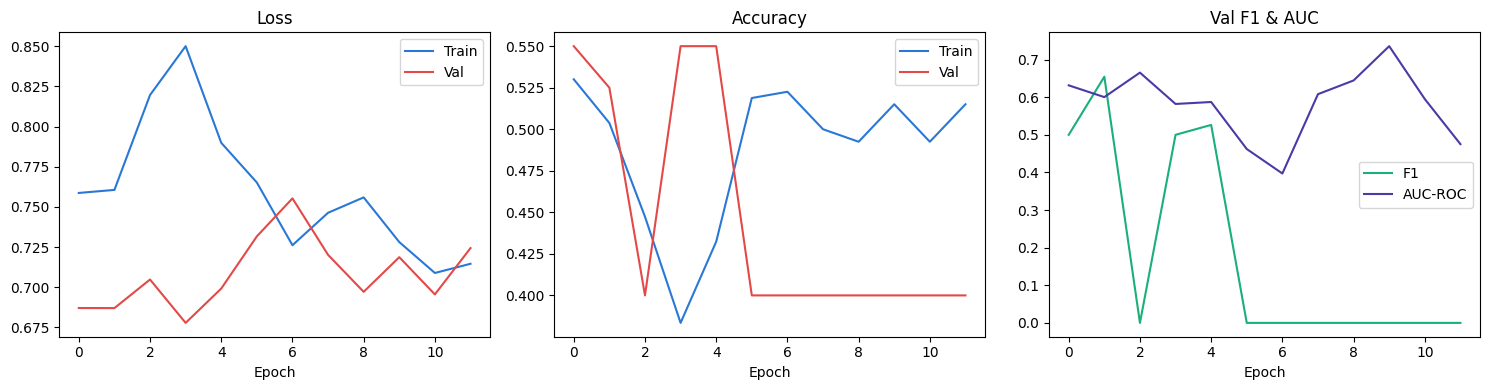

In [18]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# 📊 PLOT TRAINING HISTORY
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(history["train_loss"], label="Train", color="#2a78d6")
axes[0].plot(history["val_loss"],   label="Val",   color="#e34948")
axes[0].set_title("Loss");   axes[0].set_xlabel("Epoch"); axes[0].legend()

axes[1].plot(history["train_acc"], label="Train", color="#2a78d6")
axes[1].plot(history["val_acc"],   label="Val",   color="#e34948")
axes[1].set_title("Accuracy"); axes[1].set_xlabel("Epoch"); axes[1].legend()

axes[2].plot(history["val_f1"],  label="F1",      color="#1baf7a")
axes[2].plot(history["val_auc"], label="AUC-ROC", color="#4a3aa7")
axes[2].set_title("Val F1 & AUC"); axes[2].set_xlabel("Epoch"); axes[2].legend()

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/training_history.png", dpi=150, bbox_inches="tight")
plt.show()


In [20]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# 🧪 TEST EVALUATION
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Load best model
ckpt = torch.load(best_model_path, map_location=DEVICE, weights_only=False)
model.load_state_dict(ckpt["model_state_dict"])
print(f"Loaded best model from epoch {ckpt['epoch']}\n")

_, test_acc, test_f1, test_auc, preds, labels, probs = eval_epoch(
    model, test_loader, criterion
)

print(f"Test Accuracy : {test_acc:.4f}")
print(f"Test F1 Score : {test_f1:.4f}")
print(f"Test AUC-ROC  : {test_auc:.4f}")
print(f"\nClassification Report:")
print(classification_report(labels, preds, target_names=["Non-Anemic", "Anemic"]))

Loaded best model from epoch 2

Test Accuracy : 0.5132
Test F1 Score : 0.6263
Test AUC-ROC  : 0.5014

Classification Report:
              precision    recall  f1-score   support

  Non-Anemic       0.38      0.25      0.30        32
      Anemic       0.56      0.70      0.63        44

    accuracy                           0.51        76
   macro avg       0.47      0.48      0.46        76
weighted avg       0.49      0.51      0.49        76



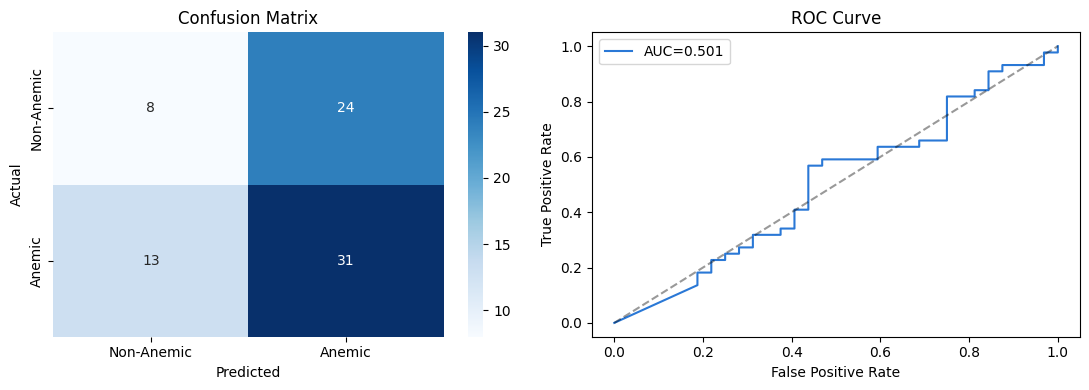

In [21]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# 📉 CONFUSION MATRIX + ROC CURVE
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Confusion matrix
cm = confusion_matrix(labels, preds)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[0],
            xticklabels=["Non-Anemic","Anemic"],
            yticklabels=["Non-Anemic","Anemic"])
axes[0].set_title("Confusion Matrix")
axes[0].set_ylabel("Actual")
axes[0].set_xlabel("Predicted")

# ROC Curve
if len(set(labels)) > 1:
    fpr, tpr, _ = roc_curve(labels, probs)
    axes[1].plot(fpr, tpr, color="#2a78d6", label=f"AUC={test_auc:.3f}")
    axes[1].plot([0,1],[0,1],"k--", alpha=0.4)
    axes[1].set_xlabel("False Positive Rate")
    axes[1].set_ylabel("True Positive Rate")
    axes[1].set_title("ROC Curve")
    axes[1].legend()

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/evaluation.png", dpi=150, bbox_inches="tight")
plt.show()


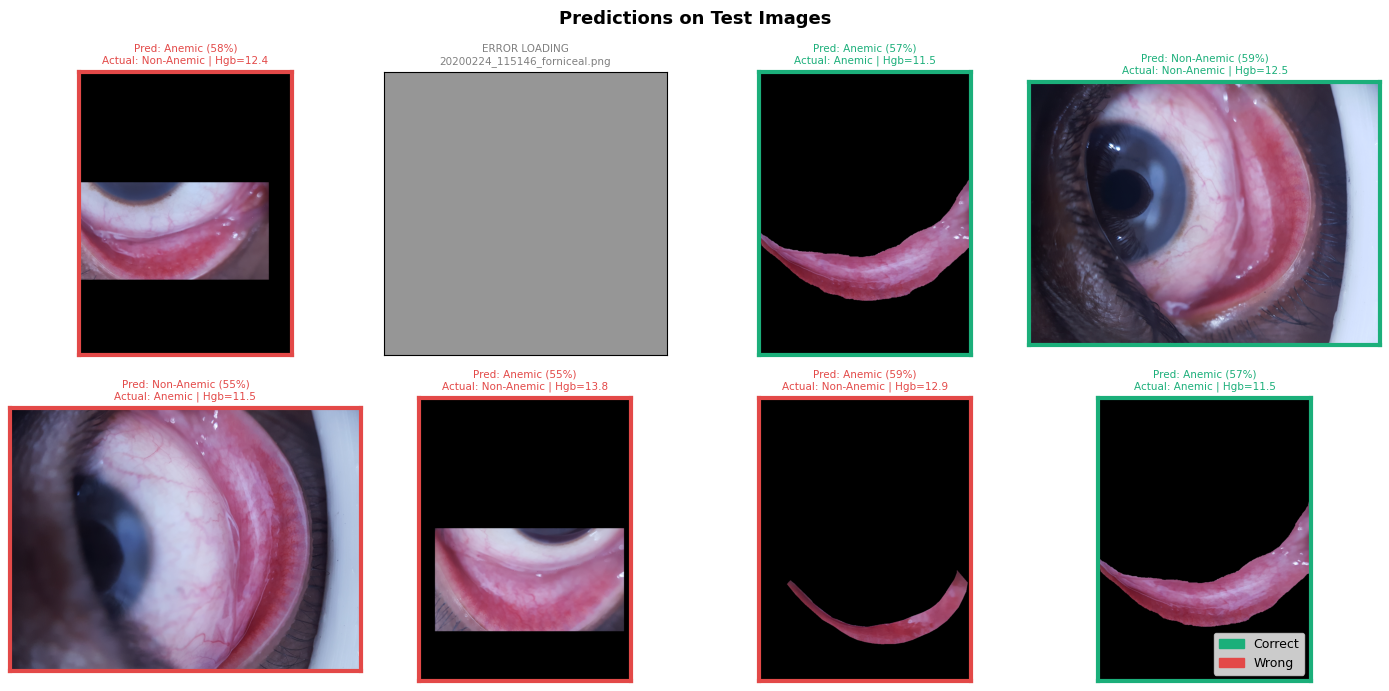

In [23]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# 🔍 VISUALIZE PREDICTIONS ON TEST IMAGES
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
def visualize_predictions(model, test_records, n=8):
    """Shows test images with predicted vs actual labels."""
    model.eval()
    sample = random.sample(test_records, min(n, len(test_records)))
    cols = 4
    rows = (len(sample) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(14, rows * 3.5))
    axes = axes.flatten() if hasattr(axes, "flatten") else [axes]

    for i, rec in enumerate(sample):
        try:
            img_pil = Image.open(rec["image_path"]).convert("RGB")
            img_t   = val_tf(img_pil).unsqueeze(0).to(DEVICE)

            with torch.no_grad():
                out   = model(img_t)
                prob  = F.softmax(out, dim=1)[0]
                pred  = out.argmax(1).item()

            actual = rec["label"]
            pred_str   = "Anemic" if pred == 1 else "Non-Anemic"
            actual_str = "Anemic" if actual == 1 else "Non-Anemic"
            conf       = prob[pred].item()
            correct    = pred == actual

            axes[i].imshow(img_pil)
            title_color = "#1baf7a" if correct else "#e34948"
            axes[i].set_title(
                f"Pred: {pred_str} ({conf:.0%})\nActual: {actual_str} | Hgb={rec['hgb']}",
                fontsize=7.5, color=title_color
            )
            border_color = "#1baf7a" if correct else "#e34948"
            for spine in axes[i].spines.values():
                spine.set_edgecolor(border_color)
                spine.set_linewidth(3)
            axes[i].set_xticks([]); axes[i].set_yticks([])
        except Exception as e:
            print(f"Warning: Could not open image {rec['image_path']}. Error: {e}")
            # Display a placeholder image for corrupted files
            img_pil = Image.new("RGB", (IMG_SIZE, IMG_SIZE), (150, 150, 150))
            axes[i].imshow(img_pil)
            axes[i].set_title(f"ERROR LOADING\n{rec['img_name']}", fontsize=7.5, color="#808080")
            axes[i].set_xticks([]); axes[i].set_yticks([])


    for j in range(i+1, len(axes)):
        axes[j].axis("off")

    correct_patch = mpatches.Patch(color="#1baf7a", label="Correct")
    wrong_patch   = mpatches.Patch(color="#e34948", label="Wrong")
    plt.legend(handles=[correct_patch, wrong_patch], loc="lower right", fontsize=9)

    plt.suptitle("Predictions on Test Images", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/test_predictions.png", dpi=120, bbox_inches="tight")
    plt.show()

visualize_predictions(model, test_recs)


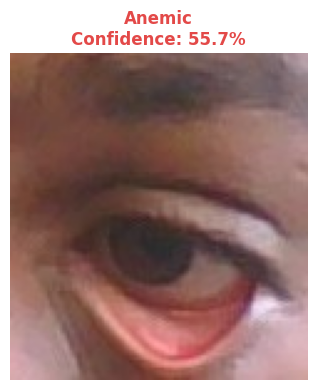

{'prediction': 'Anemic', 'confidence': 0.557, 'prob_anemic': 0.557, 'prob_normal': 0.443, 'feature_128d': array([[0.15985654, 0.        , 0.        , 0.3277641 , 0.27689594,
        0.        , 0.13763732, 0.1545752 , 0.10164899, 0.09375225,
        0.        , 0.10079352, 0.        , 0.18506262, 0.        ,
        0.01275341, 0.        , 0.        , 0.2109127 , 0.        ,
        0.        , 0.        , 0.        , 0.05013572, 0.05113677,
        0.25104135, 0.09860718, 0.        , 0.        , 0.        ,
        0.04361504, 0.37748957, 0.10532703, 0.1464127 , 0.15544036,
        0.        , 0.08960615, 0.34171483, 0.10749452, 0.09032364,
        0.        , 0.13663054, 0.00288609, 0.        , 0.        ,
        0.07840078, 0.1851493 , 0.        , 0.        , 0.        ,
        0.        , 0.01225216, 0.        , 0.07795992, 0.        ,
        0.        , 0.19268602, 0.        , 0.17695   , 0.        ,
        0.        , 0.42294267, 0.        , 0.        , 0.        ,
        0.

In [27]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# 🔬 PREDICT A SINGLE NEW IMAGE
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
def predict_image(image_path: str, model_path: str = None):
    """
    Predict anemia from a single eye image.

    Usage:
        result = predict_image("/content/drive/MyDrive/new_patient_eye.jpg")
        print(result)
    """
    if model_path:
        ckpt = torch.load(model_path, map_location=DEVICE)
        model.load_state_dict(ckpt["model_state_dict"])

    model.eval()
    img = Image.open(image_path).convert("RGB")
    inp = val_tf(img).unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        out  = model(inp)
        prob = F.softmax(out, dim=1)[0]
        pred = out.argmax(1).item()
        feat = model.extract_features(inp)

    result = {
        "prediction":    "Anemic" if pred == 1 else "Non-Anemic",
        "confidence":    round(prob[pred].item(), 4),
        "prob_anemic":   round(prob[1].item(), 4),
        "prob_normal":   round(prob[0].item(), 4),
        "feature_128d":  feat.cpu().numpy(),   # use this in fusion model
    }

    # Show image with result
    fig, ax = plt.subplots(1, 1, figsize=(4, 4))
    ax.imshow(img)
    color = "#e34948" if pred == 1 else "#1baf7a"
    ax.set_title(
        f"{result['prediction']}\nConfidence: {result['confidence']:.1%}",
        color=color, fontsize=12, fontweight="bold"
    )
    ax.axis("off")
    plt.tight_layout()
    plt.show()

    print(result)
    return result

# Example — uncomment and change path to test:
result = predict_image("/content/drive/MyDrive/new_patient_eye.jpg")


In [25]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
#  💾 DOWNLOAD MODEL TO YOUR PC
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
from google.colab import files

# Download the best model
files.download(best_model_path)

# Download plots
files.download(f"{OUTPUT_DIR}/training_history.png")
files.download(f"{OUTPUT_DIR}/evaluation.png")
files.download(f"{OUTPUT_DIR}/test_predictions.png")

print("✓ All files downloaded!")
print(f"\nFinal Summary:")
print(f"  Best Val F1  : {best_f1:.4f}")
print(f"  Test Accuracy: {test_acc:.4f}")
print(f"  Test F1      : {test_f1:.4f}")
print(f"  Test AUC     : {test_auc:.4f}")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✓ All files downloaded!

Final Summary:
  Best Val F1  : 0.6545
  Test Accuracy: 0.5132
  Test F1      : 0.6263
  Test AUC     : 0.5014
